In [32]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [33]:
print("House Price Prediction Project Started!")

House Price Prediction Project Started!


In [34]:
import os

print(os.getcwd())
print(os.listdir("../"))

C:\Users\ADITYA R T\Desktop\House price prediction\notebooks
['.ipynb_checkpoints', 'datasets', 'moldels', 'notebooks']


In [35]:
import os

for root, dirs, files in os.walk(".."):
    for file in files:
        if file.endswith(".csv"):
            print(os.path.join(root, file))

..\datasets\house_prices_clean (2).csv
..\datasets\.ipynb_checkpoints\house_prices_clean (2)-checkpoint.csv


In [36]:
import os

print(os.path.exists(r"..\datasets\house_prices_clean.csv"))

False


In [ ]:
import os

print("Current folder:")
print(os.getcwd())

print("\nFiles and folders here:")
print(os.listdir())

In [ ]:
import os

for root, dirs, files in os.walk(".."):
    for file in files:
        if file.lower().endswith(".csv"):
            print(os.path.abspath(os.path.join(root, file)))

In [ ]:
import pandas as pd

file_path = r"..\datasets\house_prices_clean (2).csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Property_ID                 2500 non-null   object 
 1   Location                    2500 non-null   object 
 2   Property_Type               2500 non-null   object 
 3   Area_SqFt                   2500 non-null   int64  
 4   Bedrooms                    2500 non-null   int64  
 5   Bathrooms                   2500 non-null   float64
 6   Floors                      2500 non-null   int64  
 7   Property_Age_Years          2500 non-null   int64  
 8   Parking_Spaces              2500 non-null   int64  
 9   Distance_to_City_Center_Km  2500 non-null   float64
 10  Nearby_Schools              2500 non-null   int64  
 11  Condition_Score             2500 non-null   int64  
 12  Location_Rating             2500 non-null   int64  
 13  Furnishing_Status           2500 

In [39]:
df.describe()

,Area_SqFt,Bedrooms,Bathrooms,Floors,Property_Age_Years,Parking_Spaces,Distance_to_City_Center_Km,Nearby_Schools,Condition_Score,Location_Rating,Price_per_SqFt,Price_INR
count,2500.000000,2500.00000,2500.000000,2500.000000,2500.000000,2500.000000,2500.00000,2500.000000,2500.000000,2500.00000,2500.000000,2.500000e+03
mean,1558.788400,2.98880,2.396600,2.502800,12.487600,1.582000,7.13248,5.124400,7.031200,6.68240,7989.793200,1.199563e+07
std,529.071299,1.21081,0.930889,1.124321,8.347078,0.774801,3.82451,2.112702,1.522614,1.24022,1586.306681,3.538672e+06
min,550.000000,1.00000,1.000000,1.000000,0.000000,0.000000,0.50000,1.000000,3.000000,4.00000,4575.000000,2.872000e+06
25%,1198.500000,2.00000,1.500000,1.000000,6.000000,1.000000,4.40000,4.000000,6.000000,6.00000,6848.250000,9.473750e+06
50%,1529.000000,3.00000,2.500000,3.000000,12.000000,2.000000,7.00000,5.000000,7.000000,7.00000,7820.000000,1.181250e+07
75%,1915.500000,4.00000,3.000000,4.000000,18.000000,2.000000,9.70000,7.000000,8.000000,8.00000,8820.250000,1.423025e+07
max,3764.000000,6.00000,5.000000,4.000000,40.000000,3.000000,21.20000,10.000000,10.000000,10.00000,16867.000000,2.614900e+07


In [40]:
df.isnull().sum()

Property_ID                   0
Location                      0
Property_Type                 0
Area_SqFt                     0
Bedrooms                      0
Bathrooms                     0
Floors                        0
Property_Age_Years            0
Parking_Spaces                0
Distance_to_City_Center_Km    0
Nearby_Schools                0
Condition_Score               0
Location_Rating               0
Furnishing_Status             0
Price_per_SqFt                0
Price_INR                     0
dtype: int64

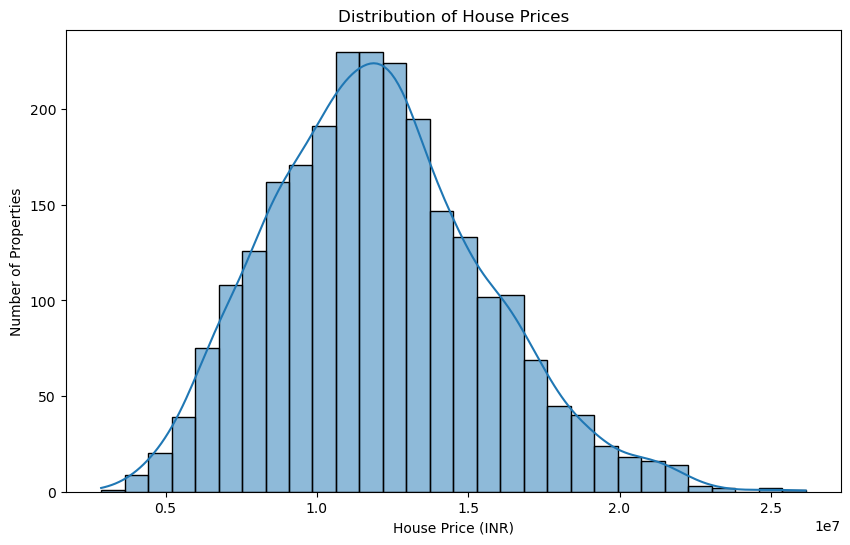

In [41]:
plt.figure(figsize=(10, 6))

sns.histplot(df["Price_INR"], bins=30, kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("House Price (INR)")
plt.ylabel("Number of Properties")

plt.show()

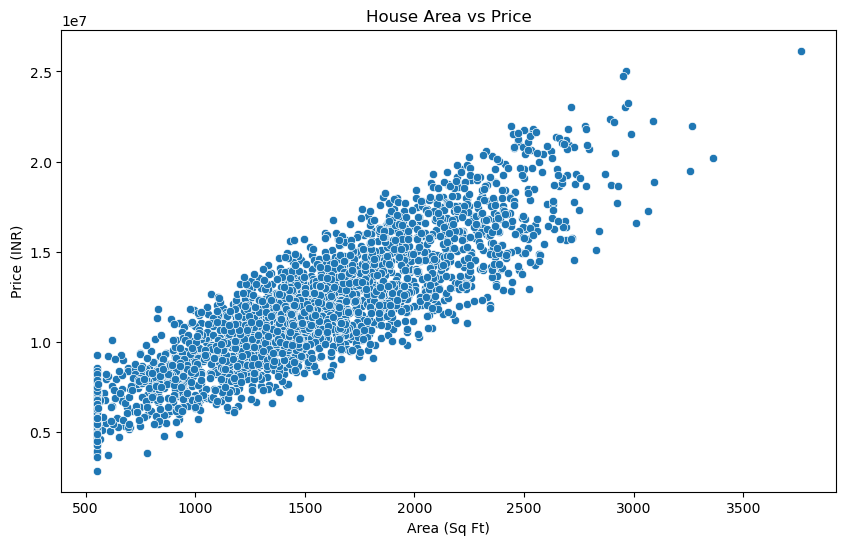

In [42]:
plt.figure(figsize=(10, 6))

sns.scatterplot(data=df, x="Area_SqFt", y="Price_INR")

plt.title("House Area vs Price")
plt.xlabel("Area (Sq Ft)")
plt.ylabel("Price (INR)")

plt.show()

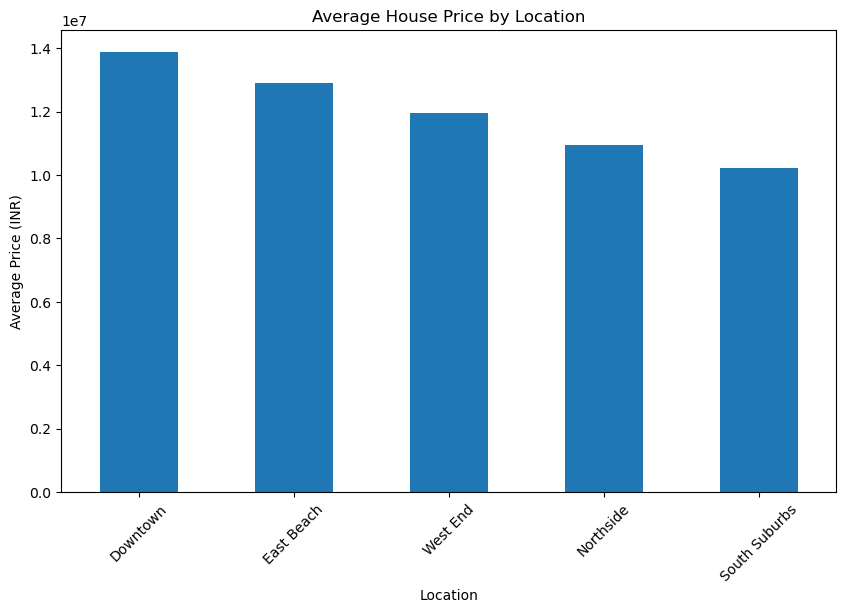

In [43]:
location_price = df.groupby("Location")["Price_INR"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))

location_price.plot(kind="bar")

plt.title("Average House Price by Location")
plt.xlabel("Location")
plt.ylabel("Average Price (INR)")
plt.xticks(rotation=45)

plt.show()

In [42]:
# Select only numerical columns
numeric_df = df.select_dtypes(include="number")

# Calculate correlation
correlation = numeric_df.corr()

# Display correlation with house price
print(correlation["Price_INR"].sort_values(ascending=False))

Price_INR                     1.000000
Area_SqFt                     0.863442
Bedrooms                      0.754508
Bathrooms                     0.683638
Parking_Spaces                0.612957
Location_Rating               0.326546
Nearby_Schools                0.080126
Condition_Score               0.047986
Floors                        0.022224
Distance_to_City_Center_Km   -0.069565
Price_per_SqFt               -0.103489
Property_Age_Years           -0.130781
Name: Price_INR, dtype: float64


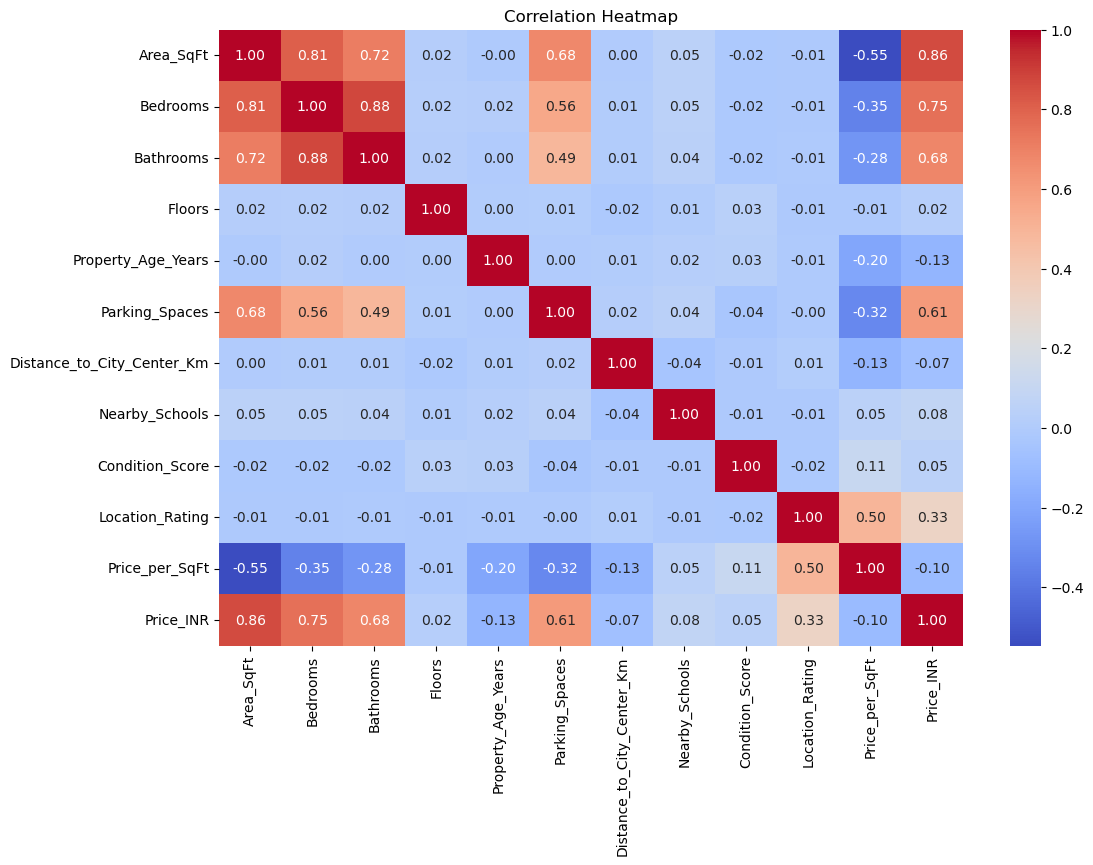

In [43]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

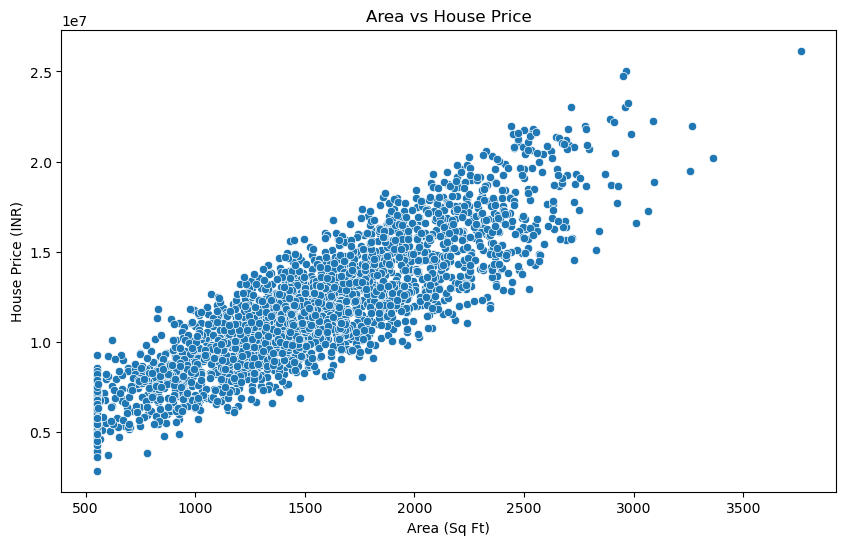

In [44]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Area_SqFt",
    y="Price_INR"
)

plt.title("Area vs House Price")
plt.xlabel("Area (Sq Ft)")
plt.ylabel("House Price (INR)")

plt.show()

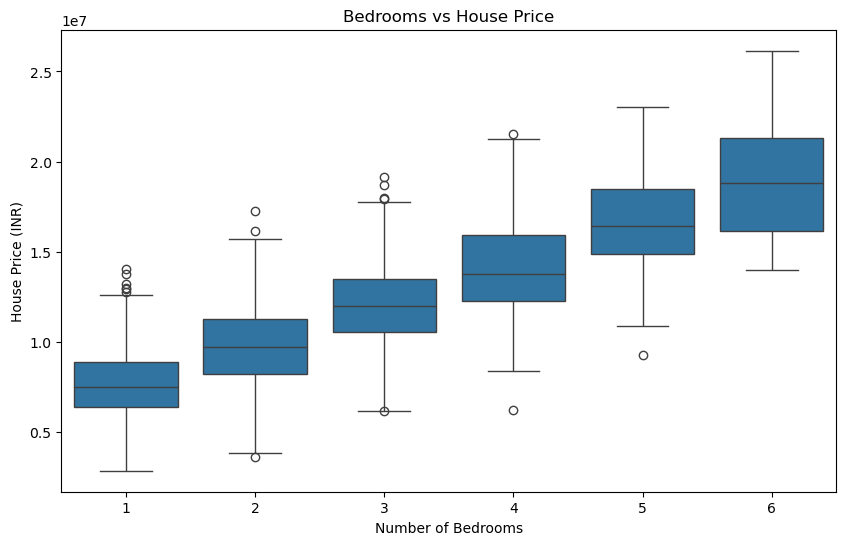

In [45]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Bedrooms",
    y="Price_INR"
)

plt.title("Bedrooms vs House Price")
plt.xlabel("Number of Bedrooms")
plt.ylabel("House Price (INR)")

plt.show()

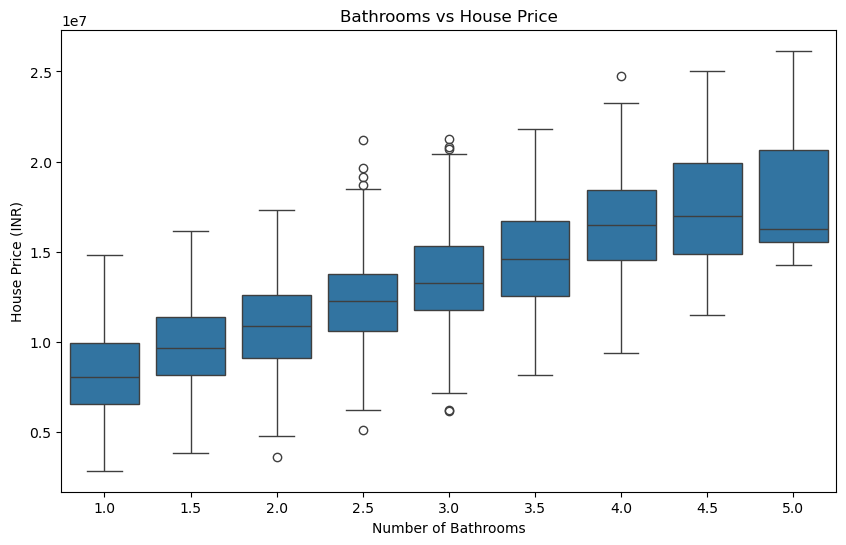

In [46]:
plt.figure(figsize=(10, 6))

sns.boxplot(x="Bathrooms", y="Price_INR", data=df)

plt.title("Bathrooms vs House Price")
plt.xlabel("Number of Bathrooms")
plt.ylabel("House Price (INR)")

plt.show()

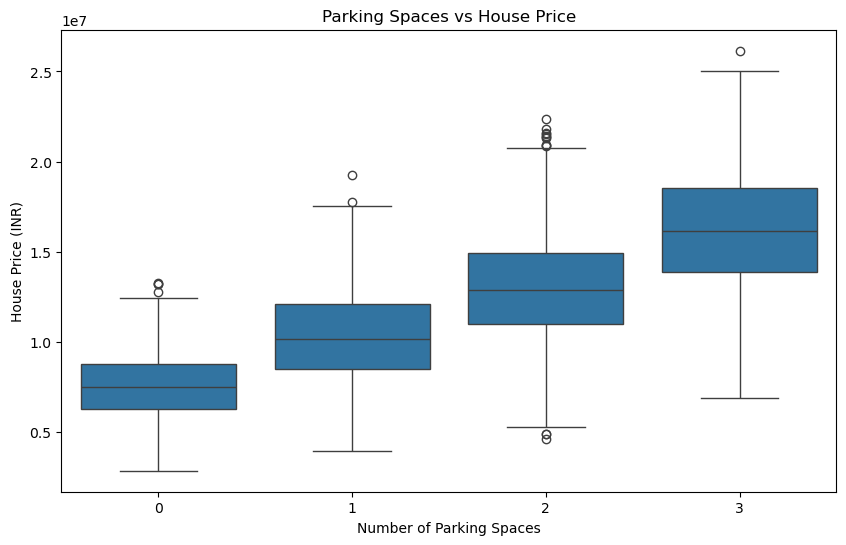

In [47]:
plt.figure(figsize=(10, 6))

sns.boxplot(x="Parking_Spaces", y="Price_INR", data=df)

plt.title("Parking Spaces vs House Price")
plt.xlabel("Number of Parking Spaces")
plt.ylabel("House Price (INR)")

plt.show()

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [1]:
plt.figure(figsize=(10, 6))

sns.boxplot(x="Location", y="Price_INR", data=df)

plt.title("Location vs House Price")
plt.xlabel("Location")
plt.ylabel("House Price (INR)")

plt.xticks(rotation=45)

plt.show()

NameError: name 'plt' is not defined

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import pandas as pd

df = pd.read_csv("../datasets/house_prices_clean (2).csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (2500, 16)


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

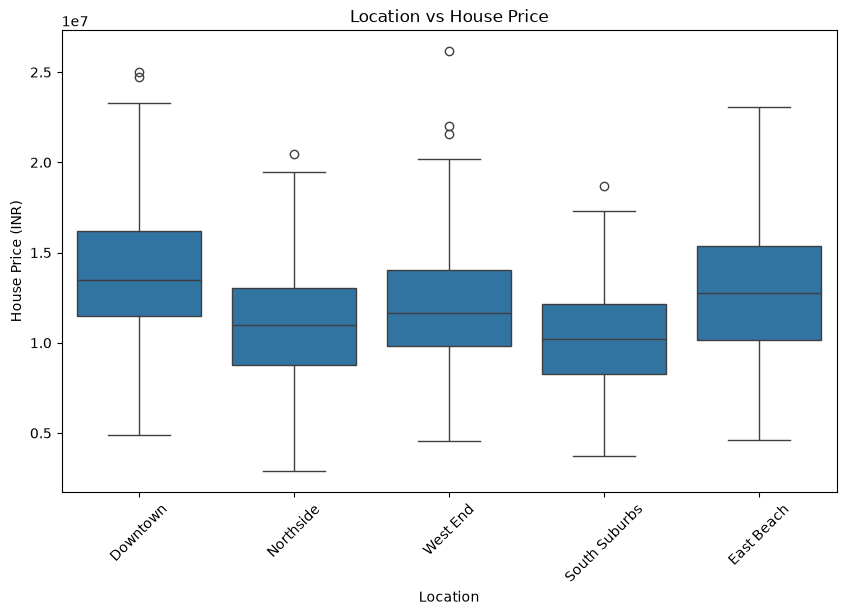

In [6]:
plt.figure(figsize=(10, 6))

sns.boxplot(x="Location", y="Price_INR", data=df)

plt.title("Location vs House Price")
plt.xlabel("Location")
plt.ylabel("House Price (INR)")

plt.xticks(rotation=45)

plt.show()

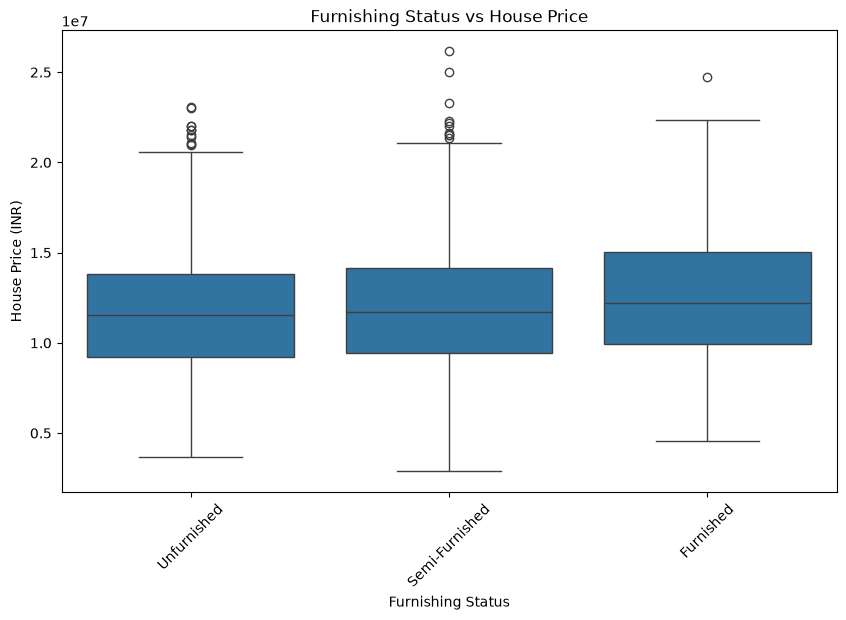

In [7]:
plt.figure(figsize=(10, 6))

sns.boxplot(x="Furnishing_Status", y="Price_INR", data=df)

plt.title("Furnishing Status vs House Price")
plt.xlabel("Furnishing Status")
plt.ylabel("House Price (INR)")

plt.xticks(rotation=45)

plt.show()

In [8]:
X = df.drop("Price_INR", axis=1)
y = df["Price_INR"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (2500, 15)
Target shape: (2500,)


In [9]:
X = X.drop("Property_ID", axis=1)

print("New features shape:", X.shape)
print(X.columns)

New features shape: (2500, 14)
Index(['Location', 'Property_Type', 'Area_SqFt', 'Bedrooms', 'Bathrooms',
       'Floors', 'Property_Age_Years', 'Parking_Spaces',
       'Distance_to_City_Center_Km', 'Nearby_Schools', 'Condition_Score',
       'Location_Rating', 'Furnishing_Status', 'Price_per_SqFt'],
      dtype='str')


In [10]:
categorical_columns = X.select_dtypes(include="object").columns

print("Categorical columns:")
print(categorical_columns)

Categorical columns:
Index(['Location', 'Property_Type', 'Furnishing_Status'], dtype='str')


C:\Users\ADITYA R T\AppData\Local\Temp\ipykernel_25012\206139453.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = X.select_dtypes(include="object").columns


In [11]:
categorical_columns = X.select_dtypes(include="str").columns

print("Categorical columns:")
print(categorical_columns)

Categorical columns:
Index(['Location', 'Property_Type', 'Furnishing_Status'], dtype='str')


In [12]:
X_encoded = pd.get_dummies(X, columns=categorical_columns, drop_first=True)

print("Original features:", X.shape)
print("Encoded features:", X_encoded.shape)
print(X_encoded.head())

Original features: (2500, 14)
Encoded features: (2500, 20)
   Area_SqFt  Bedrooms  Bathrooms  Floors  Property_Age_Years  Parking_Spaces  \
0       1371         3        3.0       2                   5               1   
1       1160         3        2.5       2                  22               1   
2       1242         2        1.5       1                  17               2   
3       2508         5        4.0       3                  21               3   
4       1719         4        3.5       2                  11               2   

   Distance_to_City_Center_Km  Nearby_Schools  Condition_Score  \
0                         7.2               4                6   
1                         6.9               4                9   
2                         2.9               4                6   
3                        10.4               1                4   
4                         6.9               2                4   

   Location_Rating  Price_per_SqFt  Location_East Beach  

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (2000, 20)
X_test: (500, 20)
y_train: (2000,)
y_test: (500,)


In [14]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [2]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(model, "../models/house_price_model.pkl")
joblib.dump(preprocessor, "../models/house_price_preprocessor.pkl")

print("Model and preprocessor saved successfully!")

NameError: name 'model' is not defined

In [15]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[ 8308592.84354484 10310243.24723993  9479097.38138033 16304389.16705278
 16168593.82307568 14929463.08625851  6330111.64145892  9170274.42463005
 13102145.53162768  7063278.43595575]


In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE : 474560.2925481526
MSE : 393762166437.7695
RMSE: 627504.7142753347
R² Score: 0.9657739983655816


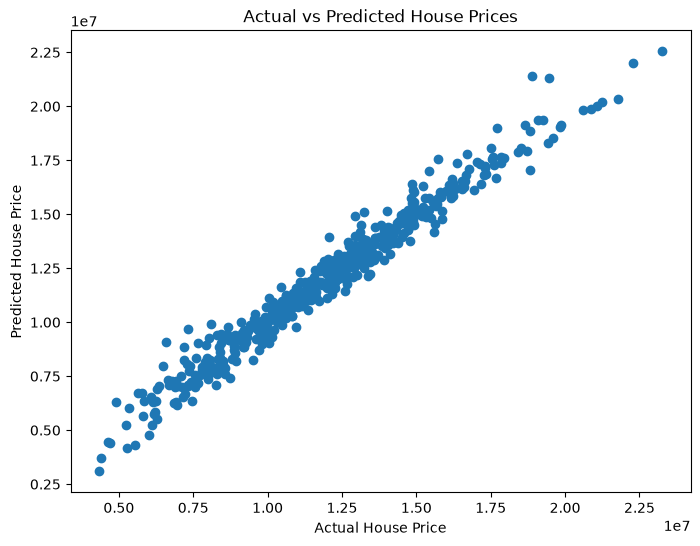

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Actual vs Predicted House Prices")

plt.show()

In [3]:
import pandas as pd

df = pd.read_csv("../datasets/house_prices_clean (2).csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)
print(df.head())

Dataset loaded successfully!
Shape: (2500, 16)
  Property_ID   Location Property_Type  Area_SqFt  Bedrooms  Bathrooms  \
0    HP100001   Downtown     Apartment       1371         3        3.0   
1    HP100002  Northside     Apartment       1160         3        2.5   
2    HP100003  Northside     Apartment       1242         2        1.5   
3    HP100004   West End         Villa       2508         5        4.0   
4    HP100005   West End     Apartment       1719         4        3.5   

   Floors  Property_Age_Years  Parking_Spaces  Distance_to_City_Center_Km  \
0       2                   5               1                         7.2   
1       2                  22               1                         6.9   
2       1                  17               2                         2.9   
3       3                  21               3                        10.4   
4       2                  11               2                         6.9   

   Nearby_Schools  Condition_Score  Location_

In [6]:
# ==========================================
# HOUSE PRICE PREDICTION - LINEAR REGRESSION
# ==========================================

import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Separate Features and Target
X = df.drop(columns=["Property_ID", "Price_INR"])
y = df["Price_INR"]

# 2. Identify Categorical and Numerical Columns
categorical_cols = X.select_dtypes(include=["object"]).columns
numerical_cols = X.select_dtypes(exclude=["object"]).columns

print("Categorical columns:", list(categorical_cols))
print("Numerical columns:", list(numerical_cols))

# 3. Encode Categorical Columns
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ],
    remainder="passthrough"
)

X_encoded = preprocessor.fit_transform(X)

# 4. Split Dataset into Training and Testing
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining data:", X_train.shape)
print("Testing data:", X_test.shape)

# 5. Create and Train Model
model = LinearRegression()
model.fit(X_train, y_train)

# 6. Predict House Prices
y_pred = model.predict(X_test)

# 7. Evaluate Model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n========== MODEL PERFORMANCE ==========")
print("Mean Absolute Error (MAE):", round(mae, 2))
print("Root Mean Squared Error (RMSE):", round(rmse, 2))
print("R² Score:", round(r2, 4))

NameError: name 'df' is not defined

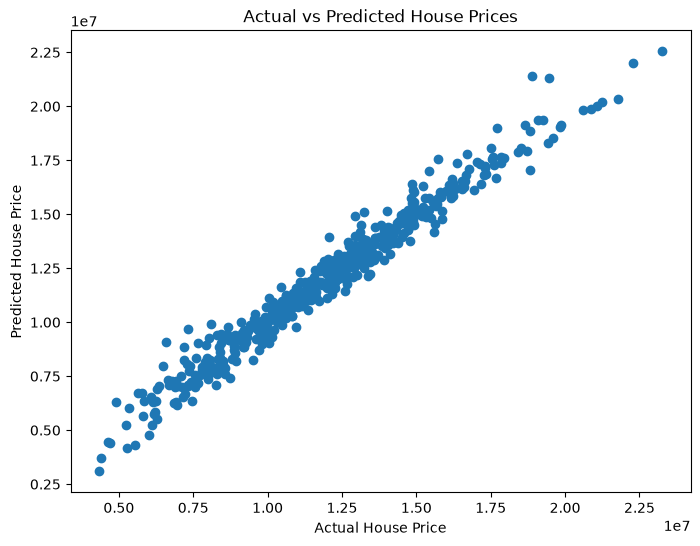

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Actual vs Predicted House Prices")

plt.show()

In [6]:
# ==========================================
# ACTUAL vs PREDICTED VALUES
# ==========================================

comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

comparison["Difference"] = (
    comparison["Actual Price"] - comparison["Predicted Price"]
)

comparison["Error %"] = (
    abs(comparison["Difference"]) / comparison["Actual Price"] * 100
)

print(comparison.head(10))

   Actual Price  Predicted Price    Difference    Error %
0       8791000     8.308593e+06  4.824072e+05   5.487512
1      10192000     1.031024e+07 -1.182432e+05   1.160157
2      10031000     9.479097e+06  5.519026e+05   5.501970
3      16551000     1.630439e+07  2.466108e+05   1.490006
4      16210000     1.616859e+07  4.140618e+04   0.255436
5      12941000     1.492946e+07 -1.988463e+06  15.365606
6       5828000     6.330112e+06 -5.021116e+05   8.615505
7       8701000     9.170274e+06 -4.692744e+05   5.393339
8      13717000     1.310215e+07  6.148545e+05   4.482427
9       6353000     7.063278e+06 -7.102784e+05  11.180205


In [7]:
# ==========================================
# MEAN ABSOLUTE PERCENTAGE ERROR
# ==========================================

mape = np.mean(
    np.abs((y_test - y_pred) / y_test)
) * 100

print("Mean Absolute Percentage Error (MAPE):", round(mape, 2), "%")


Mean Absolute Percentage Error (MAPE): 4.45 %


In [8]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)
print("Mean Absolute Percentage Error (MAPE): 4.45%")

Mean Absolute Error (MAE): 474560.29254816927
Root Mean Squared Error (RMSE): 627504.7142753352
R² Score: 0.9657739983655816
Mean Absolute Percentage Error (MAPE): 4.45%


In [10]:
print("Model expects:", model.n_features_in_, "features")
print("New house has:", new_house.shape[1], "features")

Model expects: 23 features
New house has: 14 features


In [11]:
print("Features used by the model:")
for i, feature in enumerate(X.columns, start=1):
    print(i, feature)

Features used by the model:
1 Location
2 Property_Type
3 Area_SqFt
4 Bedrooms
5 Bathrooms
6 Floors
7 Property_Age_Years
8 Parking_Spaces
9 Distance_to_City_Center_Km
10 Nearby_Schools
11 Condition_Score
12 Location_Rating
13 Furnishing_Status
14 Price_per_SqFt


In [13]:
print("Number of encoded features:", X_encoded.shape[1])

print("\nEncoded feature names:")
print(preprocessor.get_feature_names_out())

Number of encoded features: 23

Encoded feature names:
['cat__Location_Downtown' 'cat__Location_East Beach'
 'cat__Location_Northside' 'cat__Location_South Suburbs'
 'cat__Location_West End' 'cat__Property_Type_Apartment'
 'cat__Property_Type_Independent House' 'cat__Property_Type_Townhouse'
 'cat__Property_Type_Villa' 'cat__Furnishing_Status_Furnished'
 'cat__Furnishing_Status_Semi-Furnished'
 'cat__Furnishing_Status_Unfurnished' 'remainder__Area_SqFt'
 'remainder__Bedrooms' 'remainder__Bathrooms' 'remainder__Floors'
 'remainder__Property_Age_Years' 'remainder__Parking_Spaces'
 'remainder__Distance_to_City_Center_Km' 'remainder__Nearby_Schools'
 'remainder__Condition_Score' 'remainder__Location_Rating'
 'remainder__Price_per_SqFt']


In [14]:
# ==========================================
# Predict Price of a New House
# ==========================================

new_house = pd.DataFrame({
    "Location": ["Downtown"],
    "Property_Type": ["Apartment"],
    "Area_SqFt": [1500],
    "Bedrooms": [3],
    "Bathrooms": [2],
    "Floors": [2],
    "Property_Age_Years": [5],
    "Parking_Spaces": [1],
    "Distance_to_City_Center_Km": [6],
    "Nearby_Schools": [4],
    "Condition_Score": [8],
    "Location_Rating": [9],
    "Furnishing_Status": ["Unfurnished"],
    "Price_per_SqFt": [9000]
})

# Apply the SAME preprocessing used during training
new_house_encoded = preprocessor.transform(new_house)

# Predict house price
new_prediction = model.predict(new_house_encoded)

print("======================================")
print("       HOUSE PRICE PREDICTION")
print("======================================")
print("Predicted House Price: ₹", round(new_prediction[0], 2))

       HOUSE PRICE PREDICTION
Predicted House Price: ₹ 13405985.25


In [15]:
import joblib

# Save the trained model
joblib.dump(model, "house_price_model.pkl")

# Save the preprocessing pipeline
joblib.dump(preprocessor, "house_price_preprocessor.pkl")

print("Model and preprocessor saved successfully!")

Model and preprocessor saved successfully!


In [5]:
from sklearn.linear_model import LinearRegression
import joblib
import os

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully!")

# Create models folder
os.makedirs("../models", exist_ok=True)

# Save model
joblib.dump(model, "../models/house_price_model.pkl")

print("Model saved successfully!")

NameError: name 'X_train' is not defined

In [7]:
import pandas as pd

df = pd.read_csv("../datasets/house_prices_clean (2).csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (2500, 16)


In [8]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(model, "../models/house_price_model.pkl")
joblib.dump(preprocessor, "../models/house_price_preprocessor.pkl")

print("Model and preprocessor saved successfully!")

NameError: name 'preprocessor' is not defined

In [9]:
import pandas as pd
import joblib
import os

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Load dataset
df = pd.read_csv("../datasets/house_prices_clean (2).csv")

# Separate features
X = df.drop(columns=["Property_ID", "Price_INR"])

# Identify columns
categorical_cols = X.select_dtypes(include=["object"]).columns

# Create preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ],
    remainder="passthrough"
)

# Fit preprocessor
preprocessor.fit(X)

# Save it
os.makedirs("../models", exist_ok=True)
joblib.dump(preprocessor, "../models/house_price_preprocessor.pkl")

print("Preprocessor saved successfully!")

Preprocessor saved successfully!


In [11]:
import os

print(os.path.exists("house_price_model.pkl"))
print(os.path.exists("house_price_preprocessor.pkl"))

True
True


In [12]:
import joblib

model = joblib.load("house_price_model.pkl")
preprocessor = joblib.load("house_price_preprocessor.pkl")

print("Model loaded successfully!")
print("Preprocessor loaded successfully!")

Model loaded successfully!
Preprocessor loaded successfully!


D:\anaconda3\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator LinearRegression from version 1.9.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
D:\anaconda3\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator OneHotEncoder from version 1.9.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
D:\anaconda3\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator FunctionTransformer from version 1.9.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use 

In [15]:
# Test the saved model with one raw sample

sample = df.drop(columns=["Price_INR"]).iloc[[0]]

sample_transformed = preprocessor.transform(sample)

prediction = model.predict(sample_transformed)

print("Predicted House Price:", prediction[0])

Predicted House Price: 12268796.424267273


In [16]:
# Compare Actual Price vs Predicted Price

actual_price = df["Price_INR"].iloc[0]
predicted_price = prediction[0]

print("Actual House Price   :", actual_price)
print("Predicted House Price:", round(predicted_price, 2))

difference = abs(actual_price - predicted_price)

print("Difference           :", round(difference, 2))

Actual House Price   : 12205000
Predicted House Price: 12268796.42
Difference           : 63796.42


In [18]:
# ==========================================
# HOUSE PRICE MODEL - TESTING & EVALUATION
# ==========================================

import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)

# ==========================================
# 1. Load saved model and preprocessor
# ==========================================

model = joblib.load("house_price_model.pkl")
preprocessor = joblib.load("house_price_preprocessor.pkl")

print("Model and preprocessor loaded successfully!")


# ==========================================
# 2. Load dataset
# ==========================================

df = pd.read_csv(r"C:\Users\ADITYA R T\Desktop\House price prediction\datasets\house_prices_clean (2).csv")

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)


# ==========================================
# 3. Separate features and target
# ==========================================

X = df.drop("Price_INR", axis=1)
y = df["Price_INR"]


# ==========================================
# 4. Transform the complete dataset
# ==========================================

X_transformed = preprocessor.transform(X)


# ==========================================
# 5. Make predictions
# ==========================================

y_pred = model.predict(X_transformed)


# ==========================================
# 6. Compare Actual vs Predicted
# ==========================================

results = pd.DataFrame({
    "Actual Price": y.values,
    "Predicted Price": y_pred
})

results["Difference"] = (
    results["Actual Price"] - results["Predicted Price"]
)

results["Error %"] = (
    abs(results["Difference"]) /
    results["Actual Price"]
) * 100

print("\nFirst 10 Predictions:")
print(results.head(10))


# ==========================================
# 7. Model Evaluation
# ==========================================

mae = mean_absolute_error(y, y_pred)

mse = mean_squared_error(y, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y, y_pred)

mape = mean_absolute_percentage_error(y, y_pred) * 100

print("\n==========================================")
print("MODEL PERFORMANCE")
print("==========================================")

print(f"MAE  : ₹{mae:,.2f}")
print(f"MSE  : {mse:,.2f}")
print(f"RMSE : ₹{rmse:,.2f}")
print(f"R² Score : {r2 * 100:.2f}%")
print(f"MAPE : {mape:.2f}%")


# ==========================================
# 8. Actual vs Predicted Graph
# ==========================================

plt.figure(figsize=(8, 6))

plt.scatter(y, y_pred)

# Perfect prediction line
plt.plot(
    [y.min(), y.max()],
    [y.min(), y.max()],
    linestyle="--"
)

plt.xlabel("Actual House Price")

plt.ylabel("Predicted House Price")

plt.title("Actual vs Predicted House Prices")

plt.show()


# ==========================================
# 9. Test one sample
# ==========================================

sample = X.iloc[[0]]

sample_transformed = preprocessor.transform(sample)

prediction = model.predict(sample_transformed)

print("\n==========================================")
print("SINGLE HOUSE PREDICTION")
print("==========================================")

print("Actual Price     : ₹", f"{y.iloc[0]:,.2f}")
print("Predicted Price  : ₹", f"{prediction[0]:,.2f}")

Model and preprocessor loaded successfully!


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\ADITYA R T\\Desktop\\House price prediction\\datasets\\house_prices_clean (2).csv'

In [19]:
import os

print("Current working folder:")
print(os.getcwd())

print("\nFiles in current folder:")
print(os.listdir())

Current working folder:
C:\Users\ADITYA R T\OneDrive\Desktop\House price prediction\notebooks

Files in current folder:
['.ipynb_checkpoints', 'house_price_model.pkl', 'House_Price_Prediction.ipynb', 'house_price_preprocessor.pkl']


In [22]:
import os
import glob
import pandas as pd

# Search for the dataset
files = glob.glob(
    r"C:\Users\ADITYA R T\**\house_prices_clean*.csv",
    recursive=True
)

print("CSV files found:")
for file in files:
    print(file)

# Load the first matching file
if files:
    df = pd.read_csv(files[0])
    print("\nDataset loaded successfully!")
    print("Dataset path:", files[0])
    print("Dataset shape:", df.shape)
    print("\nColumns:")
    print(df.columns.tolist())
else:
    print("\nDataset not found.")

CSV files found:
C:\Users\ADITYA R T\Downloads\house_prices_clean (1).csv
C:\Users\ADITYA R T\Downloads\house_prices_clean (2).csv
C:\Users\ADITYA R T\Downloads\house_prices_clean.csv
C:\Users\ADITYA R T\OneDrive\Desktop\House price prediction\datasets\house_prices_clean (2).csv
C:\Users\ADITYA R T\OneDrive\Desktop\House price prediction\datasets\house_prices_clean.csv

Dataset loaded successfully!
Dataset path: C:\Users\ADITYA R T\Downloads\house_prices_clean (1).csv
Dataset shape: (2500, 16)

Columns:
['Property_ID', 'Location', 'Property_Type', 'Area_SqFt', 'Bedrooms', 'Bathrooms', 'Floors', 'Property_Age_Years', 'Parking_Spaces', 'Distance_to_City_Center_Km', 'Nearby_Schools', 'Condition_Score', 'Location_Rating', 'Furnishing_Status', 'Price_per_SqFt', 'Price_INR']


In [23]:
import pandas as pd

# Load dataset
df = pd.read_csv("../datasets/house_prices_clean (2).csv")

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)
print(df.head())

Dataset loaded successfully!
Dataset shape: (2500, 16)
  Property_ID   Location Property_Type  Area_SqFt  Bedrooms  Bathrooms  \
0    HP100001   Downtown     Apartment       1371         3        3.0   
1    HP100002  Northside     Apartment       1160         3        2.5   
2    HP100003  Northside     Apartment       1242         2        1.5   
3    HP100004   West End         Villa       2508         5        4.0   
4    HP100005   West End     Apartment       1719         4        3.5   

   Floors  Property_Age_Years  Parking_Spaces  Distance_to_City_Center_Km  \
0       2                   5               1                         7.2   
1       2                  22               1                         6.9   
2       1                  17               2                         2.9   
3       3                  21               3                        10.4   
4       2                  11               2                         6.9   

   Nearby_Schools  Condition_Score  L

In [24]:
import pandas as pd
import joblib

# ==========================================
# 1. Load saved model and preprocessor
# ==========================================

model = joblib.load("house_price_model.pkl")
preprocessor = joblib.load("house_price_preprocessor.pkl")

print("Model and preprocessor loaded successfully!")


# ==========================================
# 2. Load dataset
# ==========================================

df = pd.read_csv("../datasets/house_prices_clean (2).csv")

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)


# ==========================================
# 3. Separate features and target
# ==========================================

X = df.drop("Price_INR", axis=1)
y = df["Price_INR"]


# ==========================================
# 4. Transform the data
# ==========================================

X_transformed = preprocessor.transform(X)

print("Data transformed successfully!")
print("Transformed shape:", X_transformed.shape)


# ==========================================
# 5. Make predictions
# ==========================================

y_pred = model.predict(X_transformed)

print("\nPrediction successful!")
print("First 5 predictions:")

for i in range(5):
    print(
        f"Actual: ₹{y.iloc[i]:,.0f}  |  "
        f"Predicted: ₹{y_pred[i]:,.0f}"
    )

Model and preprocessor loaded successfully!
Dataset loaded successfully!
Dataset shape: (2500, 16)
Data transformed successfully!
Transformed shape: (2500, 23)

Prediction successful!
First 5 predictions:
Actual: ₹12,205,000  |  Predicted: ₹12,268,796
Actual: ₹8,791,000  |  Predicted: ₹8,450,409
Actual: ₹8,567,000  |  Predicted: ₹8,491,906
Actual: ₹16,286,000  |  Predicted: ₹17,201,208
Actual: ₹11,704,000  |  Predicted: ₹11,842,696


D:\anaconda3\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator LinearRegression from version 1.9.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
D:\anaconda3\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator OneHotEncoder from version 1.9.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
D:\anaconda3\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator FunctionTransformer from version 1.9.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use 